In [65]:
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (
    roc_curve, precision_recall_curve, roc_auc_score,
    average_precision_score, confusion_matrix,
 )
from sklearn.calibration import calibration_curve

from src.ml.labels import load_labels
from src.ml.features import load_features
from src.ml.model import load_predictions
from src.ml.meta_signal import load_meta_signal
from src.utils.performance import summary_table
from src.utils.plotting import performance_table

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [66]:
labels = load_labels()
features = load_features()
preds = load_predictions()
meta = load_meta_signal()

eval_df = preds.join(
    labels.select(["rebal_date", "symbol", "label", "ret_fwd"]),
    on=["rebal_date", "symbol"],
    how="inner",
)

prob_cols = [c for c in preds.columns if c.startswith("prob_")]
class_order = [int(c.replace("prob_", "")) for c in prob_cols]
order_idx = np.argsort(class_order)
prob_cols = [prob_cols[i] for i in order_idx]
class_order = [class_order[i] for i in order_idx]

prob_mat = eval_df.select(prob_cols).to_numpy()
y_true = eval_df["label"].to_numpy()
y_pred = np.array([class_order[i] for i in np.argmax(prob_mat, axis=1)])
p_max = prob_mat.max(axis=1)

eval_df = eval_df.with_columns([
    pl.Series("y_pred", y_pred),
    pl.Series("p_max", p_max),
])

print(f"labels   : {labels.shape}")
print(f"features : {features.shape}")
print(f"preds    : {preds.shape}")
print(f"meta     : {meta.shape}")
print(f"eval_df  : {eval_df.shape}")

labels   : (29145, 4)
features : (41607, 15)
preds    : (29145, 6)
meta     : (29145, 9)
eval_df  : (29145, 10)


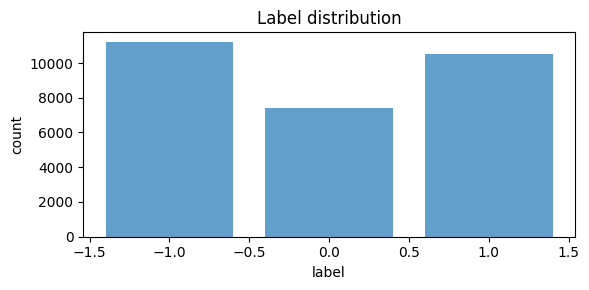

label,len
i64,u32
-1,11206
0,7430
1,10509


In [67]:
label_counts = eval_df.group_by("label").len().sort("label")
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(label_counts["label"].to_list(), label_counts["len"].to_list(), alpha=0.7)
ax.set_title("Label distribution")
ax.set_xlabel("label")
ax.set_ylabel("count")
plt.tight_layout()
save_fig("06_meta_labeling_label_dist.png")
plt.show()

label_counts

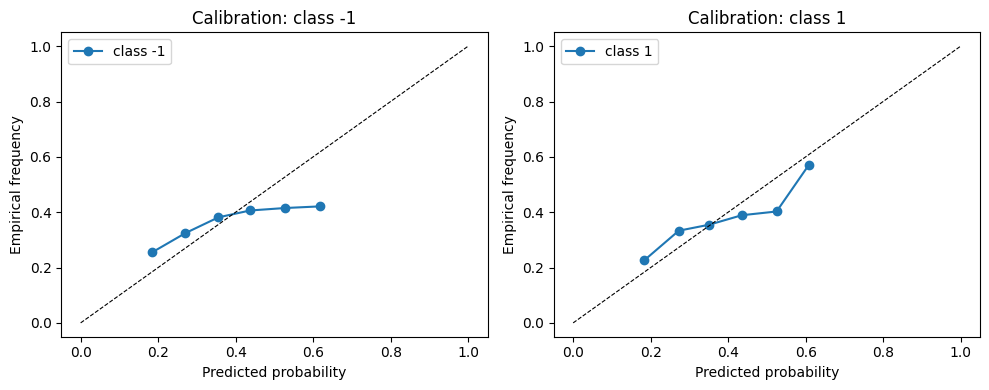

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cls in zip(axes, [-1, 1]):
    if cls not in class_order:
        ax.set_visible(False)
        continue
    idx = class_order.index(cls)
    y_bin = (y_true == cls).astype(int)
    prob = prob_mat[:, idx]
    frac_pos, mean_pred = calibration_curve(y_bin, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=f'class {cls}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'Calibration: class {cls}')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Empirical frequency')
    ax.legend()

plt.tight_layout()
save_fig("06_meta_labeling_calibration.png")
plt.show()

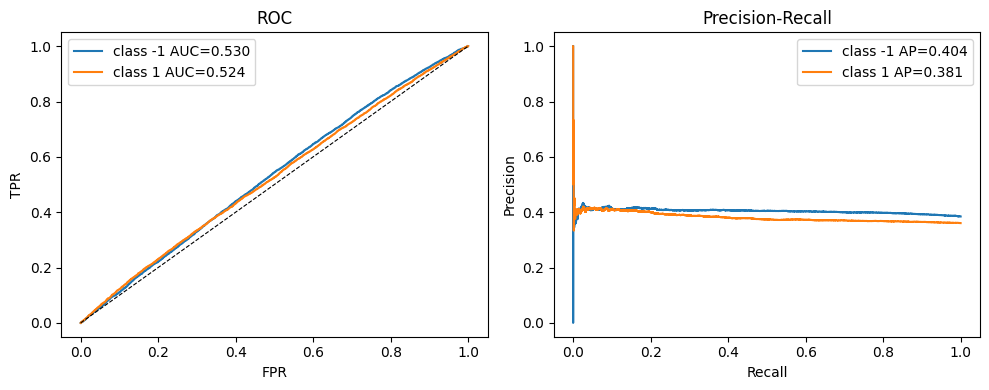

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for cls in [-1, 1]:
    if cls not in class_order:
        continue
    idx = class_order.index(cls)
    y_bin = (y_true == cls).astype(int)
    prob = prob_mat[:, idx]
    fpr, tpr, _ = roc_curve(y_bin, prob)
    auc = roc_auc_score(y_bin, prob)
    axes[0].plot(fpr, tpr, label=f'class {cls} AUC={auc:.3f}')

    precision, recall, _ = precision_recall_curve(y_bin, prob)
    ap = average_precision_score(y_bin, prob)
    axes[1].plot(recall, precision, label=f'class {cls} AP={ap:.3f}')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].set_title('Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
save_fig("06_meta_labeling_roc_pr.png")
plt.show()

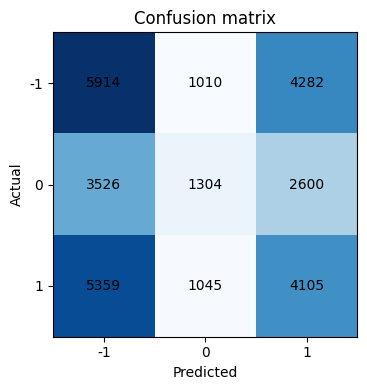

In [70]:
cm = confusion_matrix(y_true, y_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion matrix")
ax.set_xticks(range(len(class_order)))
ax.set_yticks(range(len(class_order)))
ax.set_xticklabels(class_order)
ax.set_yticklabels(class_order)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
save_fig("06_meta_labeling_confusion.png")
plt.show()

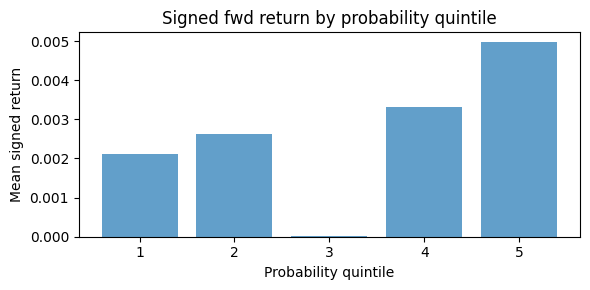

quintile,mean_signed_ret
i64,f64
1,0.002113
2,0.002634
3,0.000014
4,0.003327
5,0.004974


In [71]:
p_max = eval_df["p_max"].to_numpy()
y_pred_arr = eval_df["y_pred"].to_numpy()
ret_fwd = eval_df["ret_fwd"].to_numpy()

mask = y_pred_arr != 0
p_max = p_max[mask]
signed_ret = (ret_fwd[mask] * y_pred_arr[mask])

bins = np.quantile(p_max, np.linspace(0, 1, 6))
bin_idx = np.digitize(p_max, bins[1:-1], right=True)
bin_means = [signed_ret[bin_idx == i].mean() if (bin_idx == i).any() else 0.0 for i in range(5)]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), bin_means, alpha=0.7)
ax.set_title("Signed fwd return by probability quintile")
ax.set_xlabel("Probability quintile")
ax.set_ylabel("Mean signed return")
plt.tight_layout()
save_fig("06_meta_labeling_pnl_bins.png")
plt.show()

pl.DataFrame({"quintile": range(1, 6), "mean_signed_ret": bin_means})

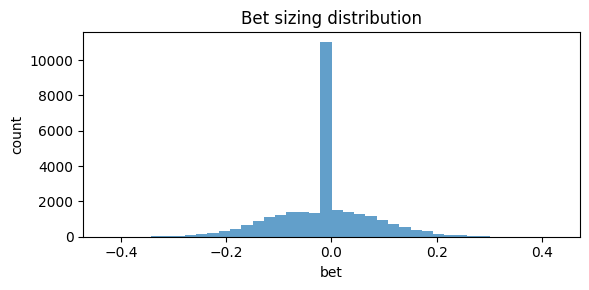

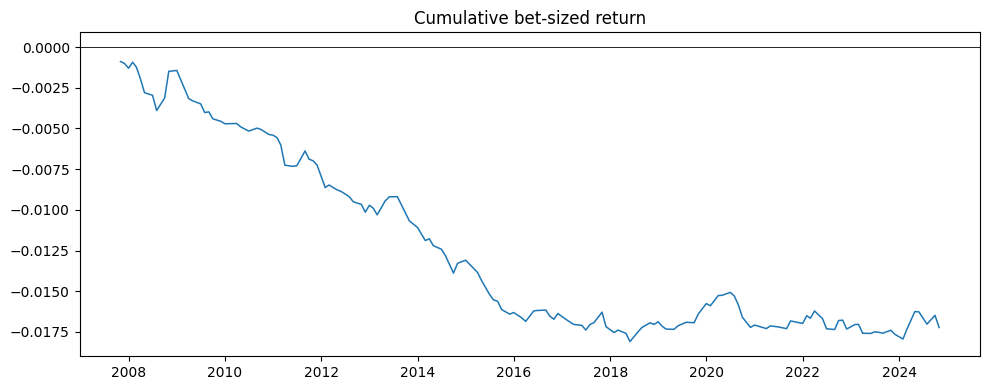

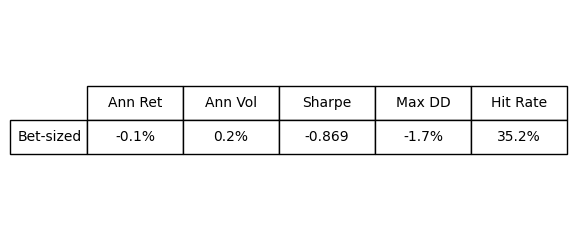

In [72]:
eval_df = eval_df.join(
    meta.select(["rebal_date", "symbol", "prob_correct", "z_score"]),
    on=["rebal_date", "symbol"],
    how="inner"
)

eval_df = eval_df.with_columns(
    ((pl.col("prob_correct") - 1/3) / (2/3)).clip(0, 1).alias("bet_raw")
).with_columns(
    (pl.col("bet_raw") * pl.col("z_score").sign()).alias("bet"),
    (pl.col("bet_raw") * pl.col("z_score").sign() * pl.col("ret_fwd")).alias("bet_ret"),
)

bet_arr = eval_df["bet"].to_numpy()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(bet_arr, bins=40, alpha=0.7)
ax.set_title("Bet sizing distribution")
ax.set_xlabel("bet")
ax.set_ylabel("count")
plt.tight_layout()
save_fig("06_meta_labeling_bet_dist.png")
plt.show()

daily = (
    eval_df
    .group_by("rebal_date")
    .agg(pl.col("bet_ret").mean().alias("bet_ret"))
    .sort("rebal_date")
)
dates = [datetime.strptime(str(d), "%Y-%m-%d") for d in daily["rebal_date"].to_list()]
bet_ret = daily["bet_ret"].to_numpy()
cum = np.exp(np.cumsum(bet_ret)) - 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, cum, linewidth=1.1)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_title("Cumulative bet-sized return")
plt.tight_layout()
save_fig("06_meta_labeling_bet_cum.png")
plt.show()

summary = summary_table(bet_ret)
fig, ax = plt.subplots(figsize=(6, 2.5))
performance_table({"Bet-sized": summary}, ax=ax)
plt.tight_layout()
save_fig("06_meta_labeling_bet_perf.png")
plt.show()